# Filtering TM/TR CDF plot (0614)

注意，_tf/_filt，增加了nsamp参数前缀。

Full c920bn3 run:
```bash
cd ~/code/TacVar && source env.bash
cd stencil
DATE_BASE=20260614 DATE_STAMP=full-stencil-0614-c920bn3 ./run_entry_filt.0614.sh
```

Pull results back to af309:
```bash
ssh af309 'mkdir -p /astrum/home/hpchzy/code/data/20260614/c920bn3/output_filt'
scp -r c920bn3:/home/hpchzy/code/data/20260614/c920bn3/output_filt/full-stencil-0614-c920bn3 \
  af309:/astrum/home/hpchzy/code/data/20260614/c920bn3/output_filt/
```

Execute on af309:
```bash
cd ~/code/TacVar
jupyter nbconvert --to notebook --execute stencil/plot_entry_filt.0614.ipynb \
  --output plot_entry_filt.0614.executed.ipynb \
  --output-dir stencil
```

This notebook reads `RUN_ROOTS` and `SHUFFLE_SELECT` below. By default it loads only `shuffle0` from the full c920bn3 run, so figures remain comparable and do not duplicate shuffle repetitions.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
RUN_ROOTS = [
    Path('/astrum/home/hpchzy/code/data/20260614/c920bn3/output_filt/full-stencil-0614-c920bn3/'),
]

SHUFFLE_SELECT = "shuffle0"

def normalize_run_roots(run_roots, shuffle_select=SHUFFLE_SELECT):
    roots = []
    for root in run_roots:
        root = Path(root)
        if root.name.startswith("shuffle"):
            roots.append(root)
        else:
            roots.append(root / shuffle_select)
    return roots

DATA_FOLDERS = normalize_run_roots(RUN_ROOTS)

# QUANTILE_DROP = 0.995  # only draw CDF values from 0 to 0.995; no data deletion, no renormalization
QUANTILE_DROP = 0.99  # only draw CDF values from 0 to 1.0; no data deletion, no renormalization
SAVE_FIG = False
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0614')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#00a6d6',
    'cntvcto': '#e377c2',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

KERNEL_LABELS = {
    'jacobi2d5p': '2D 5-Point Jacobi Stencil',
}

HOST_LABELS = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}


In [3]:
def parse_filt_dir(path):
    m = re.match(r'(?P<kernel>.+)_(?P<timer>.+?)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid', 'cntvct', 'cntvcto']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df = df[df['prob'] > 0]
    df.sort_values('ns', inplace=True)
    df['cdf'] = df['prob'].cumsum()
    if len(df) and df['cdf'].iloc[-1] != 0:
        df['cdf'] = df['cdf'] / df['cdf'].iloc[-1]
    df = df[df['cdf'] <= QUANTILE_DROP]
    if len(df):
        first = df.iloc[[0]].copy()
        first['prob'] = 0.0
        first['cdf'] = 0.0
        df = pd.concat([first, df], ignore_index=True)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
print(f'entries: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)
entries = entries[(entries['timer'] != 'tsc_native') & (entries['timer'] != 'cntvct')]
# entries = entries[(entries['timer'] != 'papi') & (entries['timer'] != 'cgt')]


entries: 108


# ER/EP/Wasserstein

In [4]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)
df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
5,c920bn3,gs2d5p,cgt,64,64,0.000000,0.010123,3.667337,0.000000,0.000000
11,c920bn3,gs2d5p,cntvcto,64,64,0.004129,0.015173,5.447236,9.022333,9.022330
17,c920bn3,gs2d5p,papi,64,64,0.000025,0.007751,3.827136,3.811289,3.811300
23,c920bn3,gs2d5p,papix6,64,64,0.001494,0.007683,3.830151,8.113980,8.113988
29,c920bn3,gs2d5p,wtime,64,64,0.000000,0.010717,3.900503,0.000000,0.000000
1,c920bn3,gs2d5p,cgt,64,128,0.000000,0.004021,2.878392,0.000000,0.000000
7,c920bn3,gs2d5p,cntvcto,64,128,0.000000,0.004856,3.460302,0.000000,0.000000
13,c920bn3,gs2d5p,papi,64,128,0.015996,0.005652,4.798995,6.486709,6.210130
19,c920bn3,gs2d5p,papix6,64,128,0.001411,0.005238,4.459296,11.017857,10.949990
25,c920bn3,gs2d5p,wtime,64,128,0.002131,0.011139,7.989950,7.255481,7.255480


In [5]:
df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])


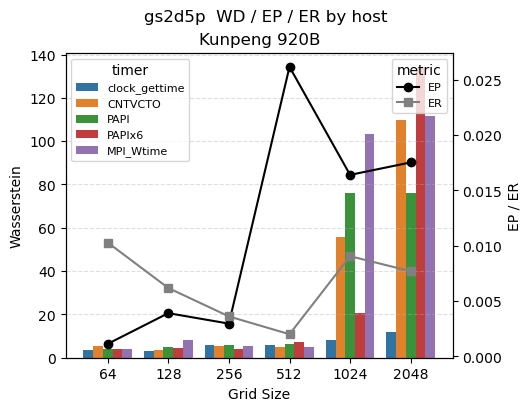

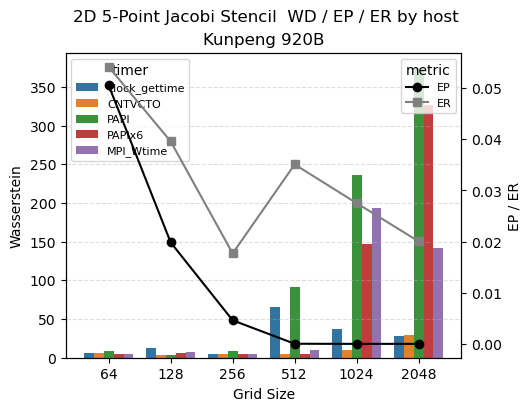

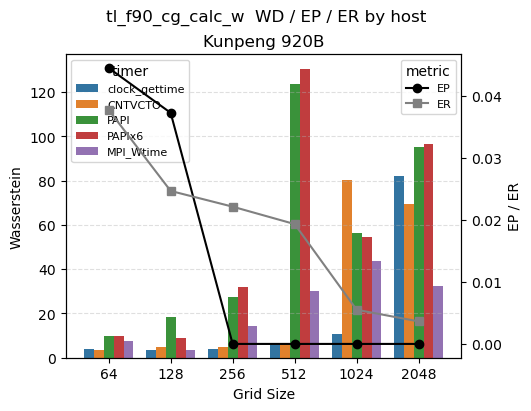

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metric_bar = 'wd'
line_metrics = ['ep', 'er']

plot_df = df.copy()
plot_df['timer_label'] = plot_df['timer'].map(TIMER_LABELS).fillna(plot_df['timer'])
plot_df['kernel_label'] = plot_df['kernel'].map(KERNEL_LABELS).fillna(plot_df['kernel'])
plot_df['size_str'] = plot_df['size'].astype(str)
size_order = [str(x) for x in sorted(plot_df['size'].unique())]
plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]
kernels = sorted(plot_df['kernel'].dropna().unique())

for kernel in kernels:
    kernel_df = plot_df[plot_df['kernel'] == kernel].copy()
    if kernel_df.empty:
        continue

    fig, axes = plt.subplots(1, len(hosts), figsize=(5.2 * len(hosts), 4), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    right_axes = []
    for ax1, host in zip(axes, hosts):
        host_df = kernel_df[kernel_df['host'] == host]
        host_label = HOST_LABELS.get(host, host)
        ax1.set_title(host_label)
        ax1.set_xlabel('Grid Size')
        ax1.set_ylabel('Wasserstein' if ax1 is axes[0] else '')
        ax1.grid(axis='y', linestyle='--', alpha=0.4)

        ax2 = ax1.twinx()
        right_axes.append(ax2)
        ax2.set_ylabel('EP / ER')

        if host_df.empty:
            ax1.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax1.transAxes)
            ax1.set_xticks([])
            ax2.set_yticks([])
            continue

        sns.barplot(data=host_df, x='size_str', y=metric_bar, hue='timer_label', ax=ax1)

        line_df = host_df.groupby(['size_str'], observed=True)[line_metrics].mean().reset_index()
        x_pos = range(len(line_df))
        ax2.plot(x_pos, line_df['ep'], marker='o', label='EP', color='black')
        ax2.plot(x_pos, line_df['er'], marker='s', label='ER', color='gray')
        ax2.set_xticks(list(x_pos))
        ax2.set_xticklabels(line_df['size_str'])

        ax1.legend(title='timer', fontsize=8, loc='upper left')
        ax2.legend(title='metric', fontsize=8, loc='upper right')

    left_lims = [ax.get_ylim() for ax in axes]
    right_lims = [ax.get_ylim() for ax in right_axes]
    left_ylim = (min(lo for lo, hi in left_lims), max(hi for lo, hi in left_lims))
    right_ylim = (min(lo for lo, hi in right_lims), max(hi for lo, hi in right_lims))
    for ax in axes:
        ax.set_ylim(left_ylim)
    for ax in right_axes:
        ax.set_ylim(right_ylim)

    kernel_label = kernel_df['kernel_label'].iloc[0]
    fig.suptitle(f'{kernel_label}  {metric_bar.upper()} / EP / ER by host')

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out = OUT_DIR / f'{kernel}_wd_ep_er_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()


# Filt Plot

In [7]:
entries['nsamp'].unique()

array([16416,  2088, 32801,  4118,  8236,  1044, 16414,  2059, 32799,
        8207, 16793,  2465, 33236,  4495,  8613,  1421, 16820, 33265,
        4524,  1450, 12124,   435, 25520,   754,  2784,   232, 12006,
         377, 25607,   696,  2668, 12385,   783, 25406,  1131,  2697,
         609, 12441,   812, 25085,  2726,   638, 12185, 27059,   667,
       61079,  1827,  8497, 24737, 59392,  1624,  6989, 27521,  1073,
       61514,  2320,  9050, 27494, 61572,  2291,  8961, 27120, 61166])

               kernel  timer  np  size  nsampRatio  nsamp     host  \
0              gs2d5p    cgt  64  1024         0.5  16416  c920bn3   
1              gs2d5p    cgt  64   128         0.5   2088  c920bn3   
2              gs2d5p    cgt  64  2048         0.5  32801  c920bn3   
3              gs2d5p    cgt  64   256         0.5   4118  c920bn3   
4              gs2d5p    cgt  64   512         0.5   8236  c920bn3   
..                ...    ...  ..   ...         ...    ...      ...   
103  tl_f90_cg_calc_w  wtime  64   128         0.5    667  c920bn3   
104  tl_f90_cg_calc_w  wtime  64  2048         0.5  61166  c920bn3   
105  tl_f90_cg_calc_w  wtime  64   256         0.5   1827  c920bn3   
106  tl_f90_cg_calc_w  wtime  64   512         0.5   8497  c920bn3   
107  tl_f90_cg_calc_w  wtime  64    64         0.5    377  c920bn3   

                                           data_folder   shuffle  \
0    /astrum/home/hpchzy/code/data/20260614/c920bn3...  shuffle0   
1    /astrum/home/hpchz

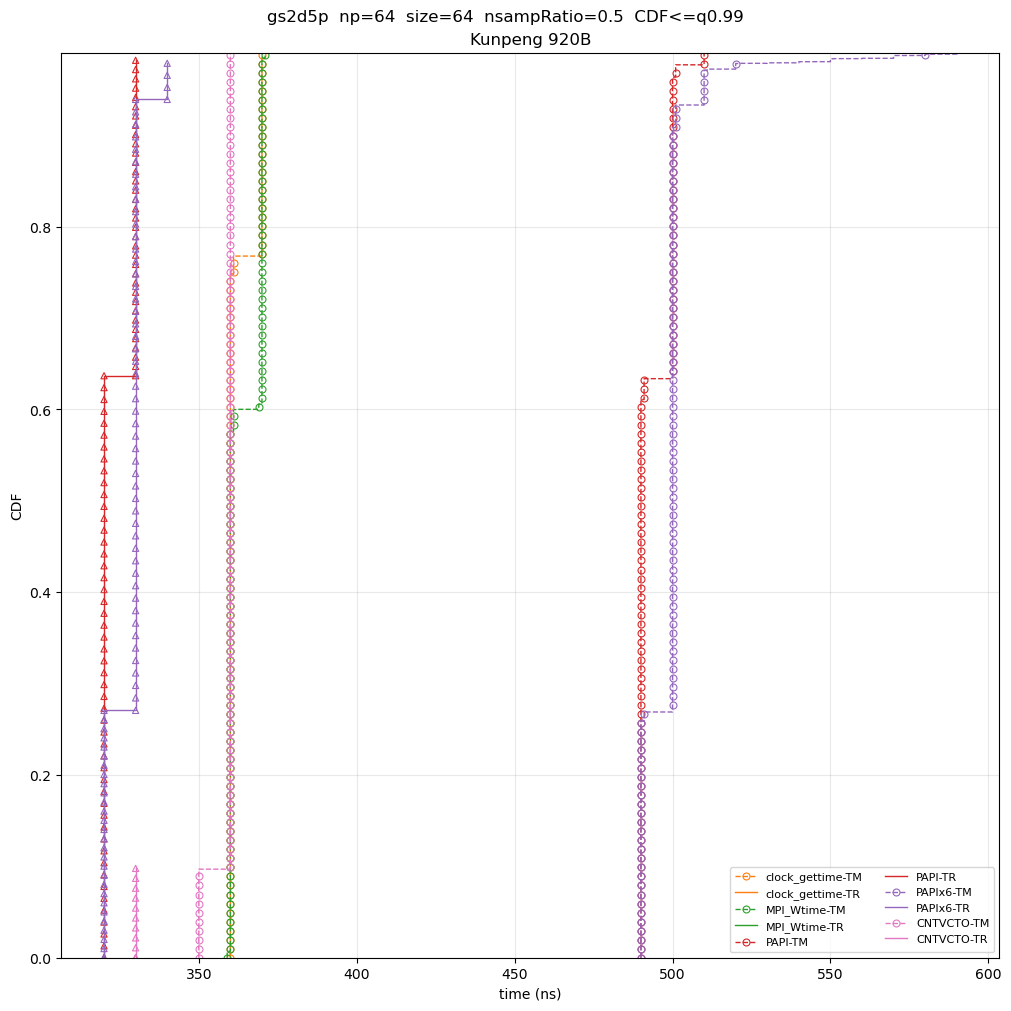

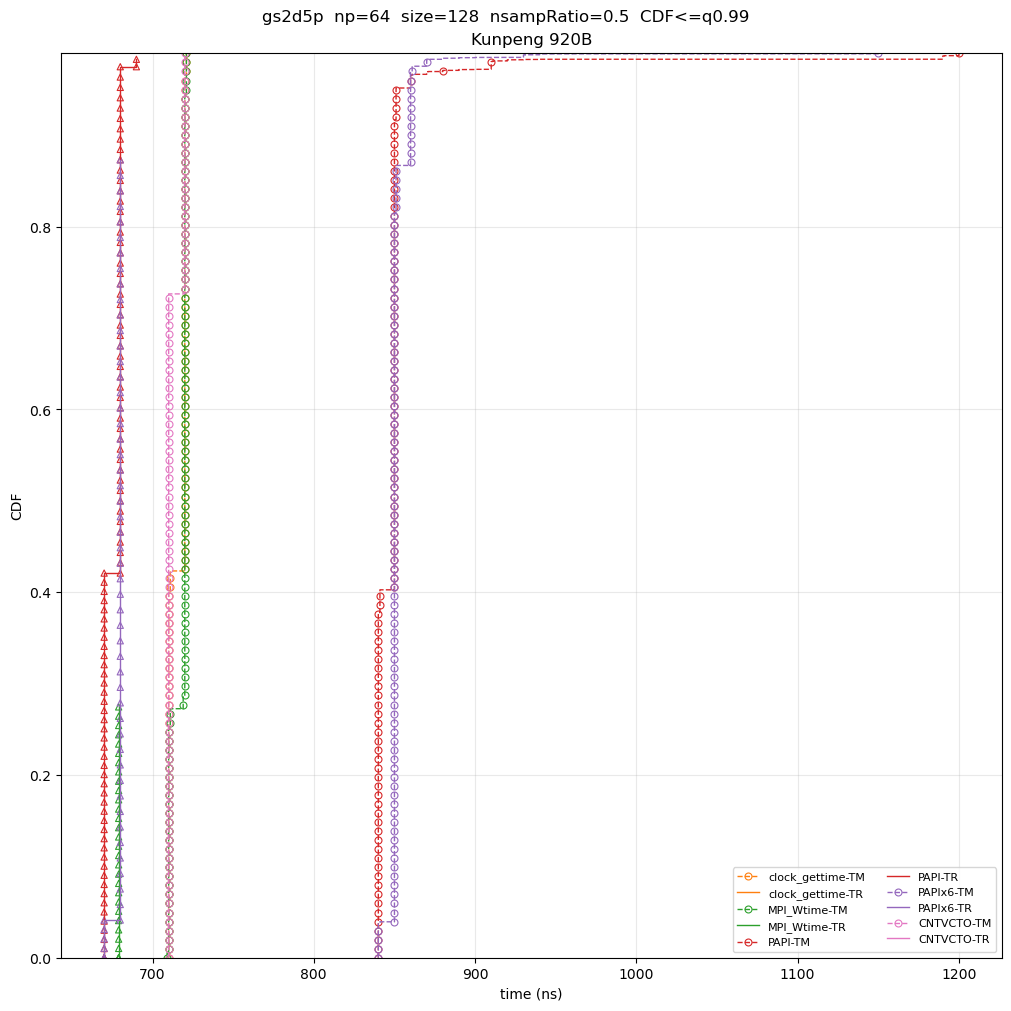

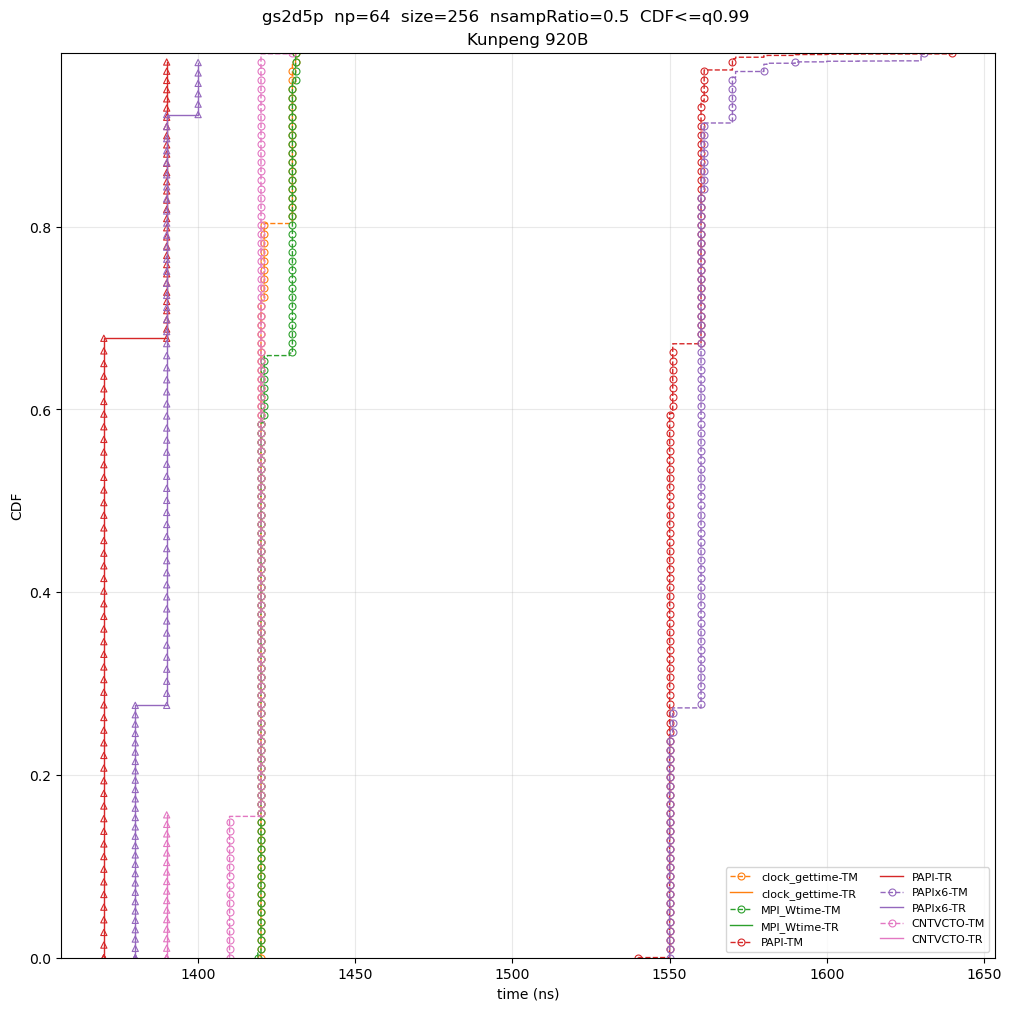

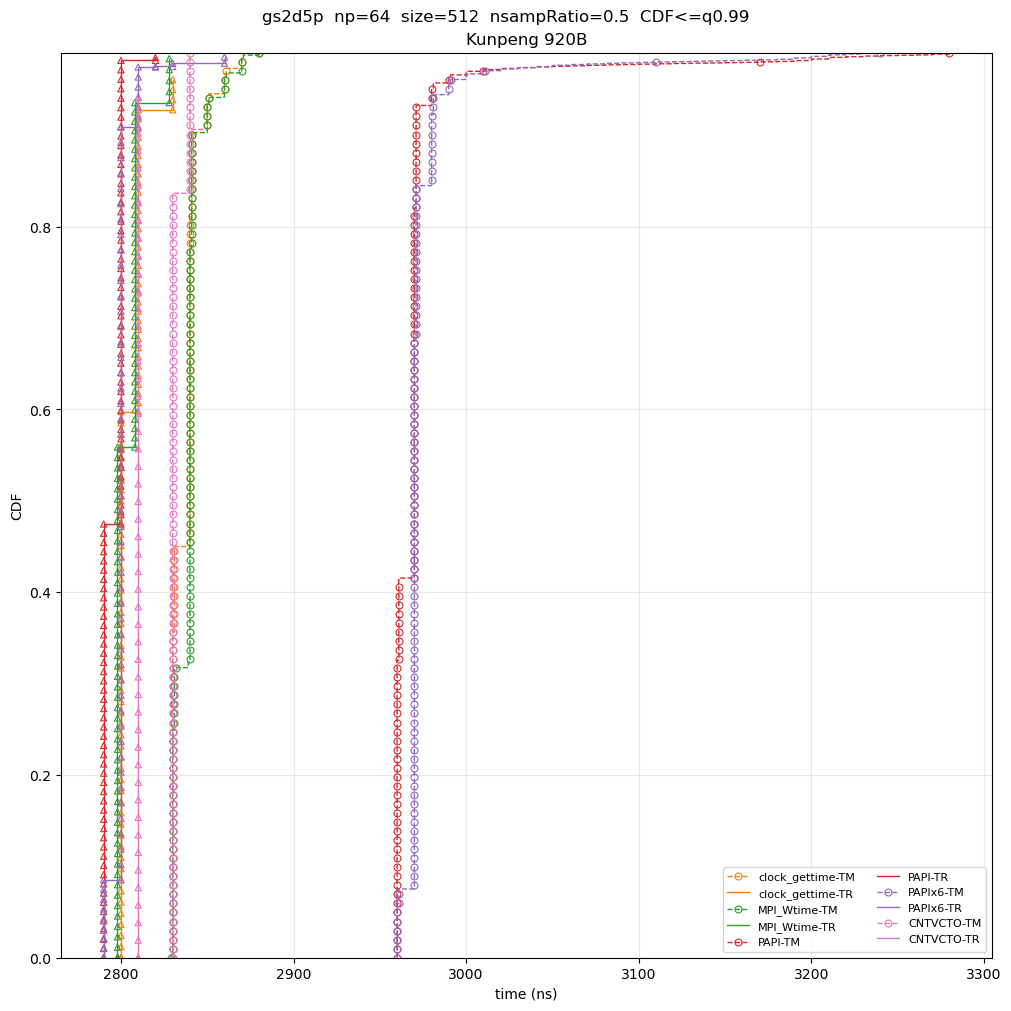

/astrum/home/hpchzy/miniconda3/envs/xfold-scripts/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


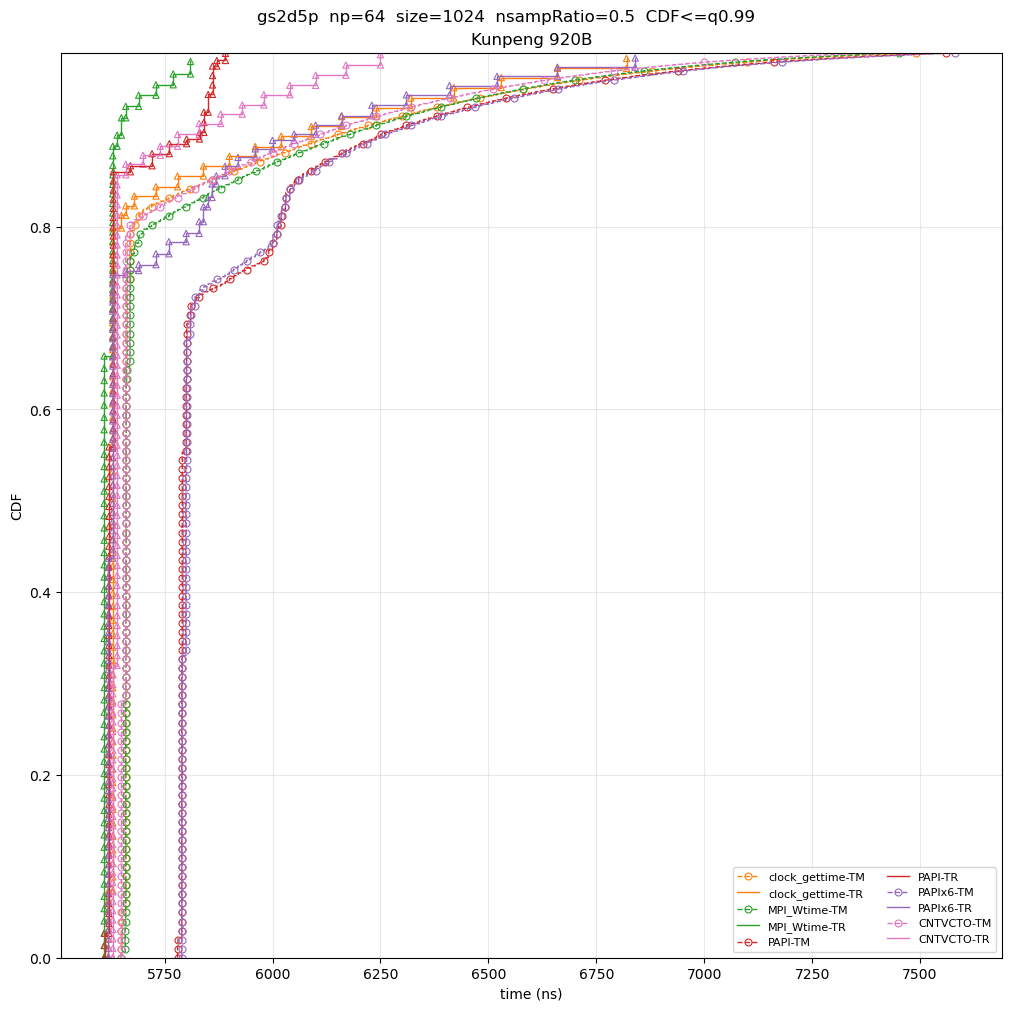

/astrum/home/hpchzy/miniconda3/envs/xfold-scripts/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


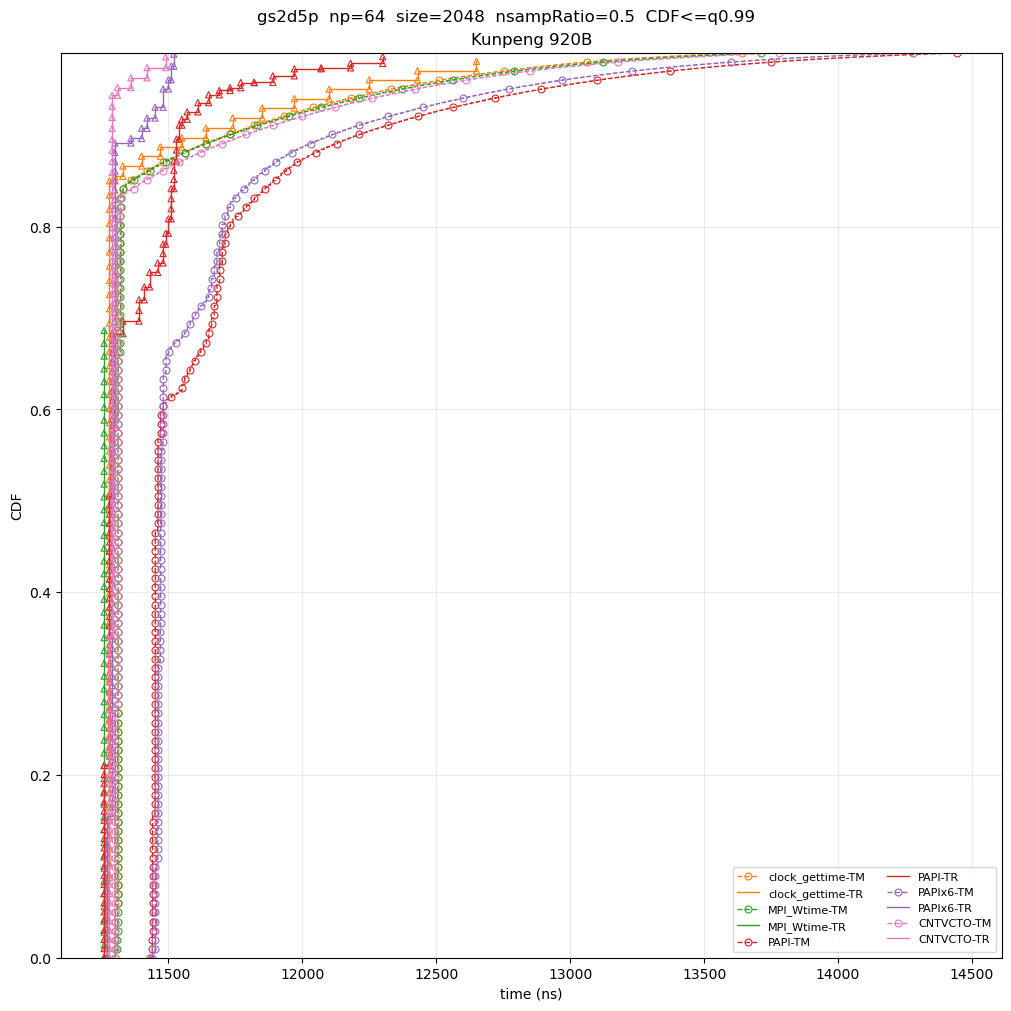

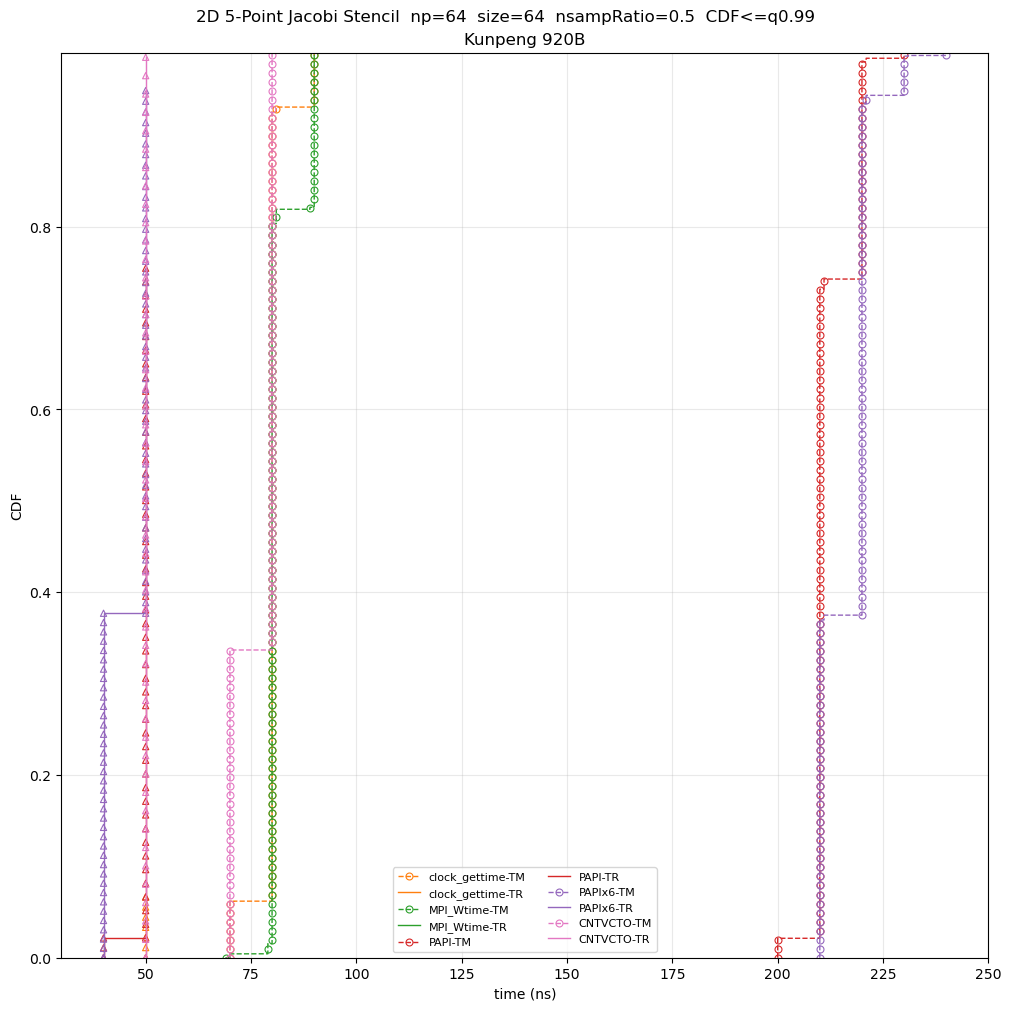

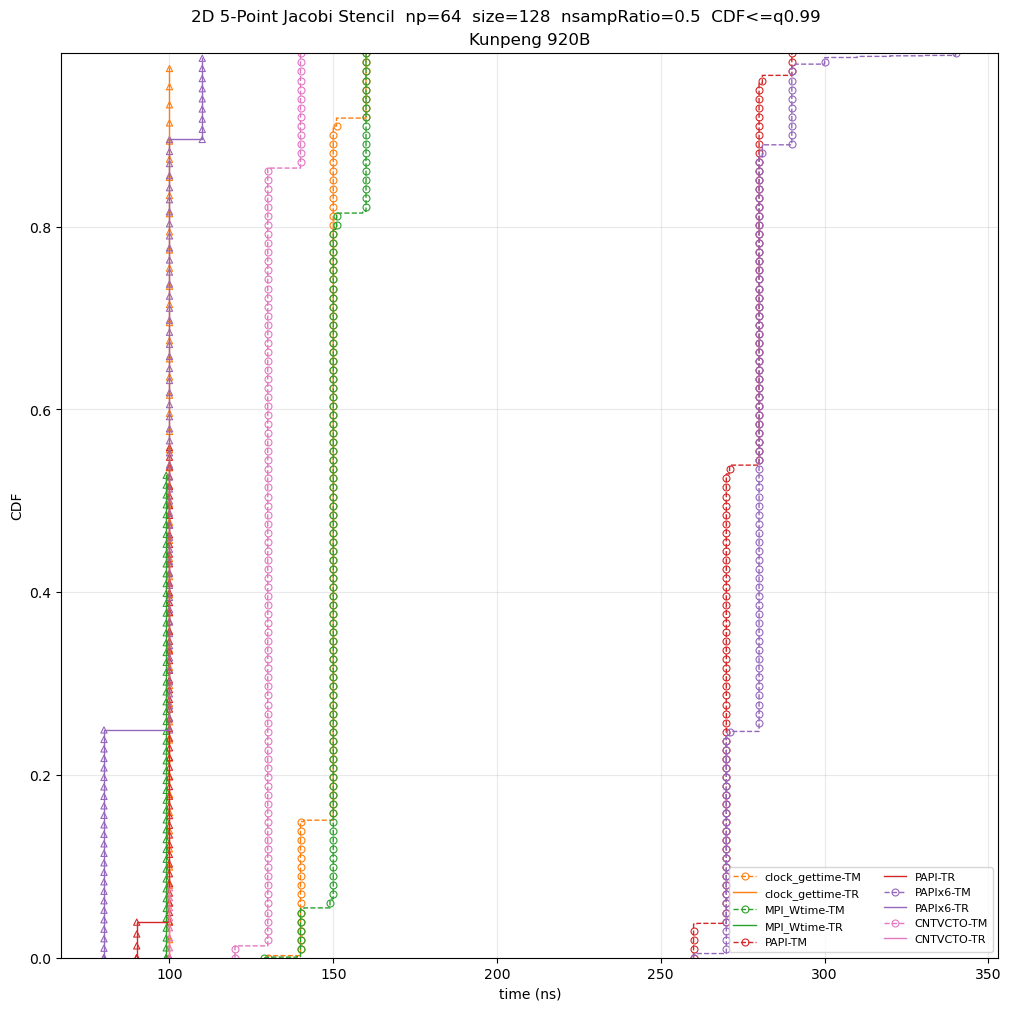

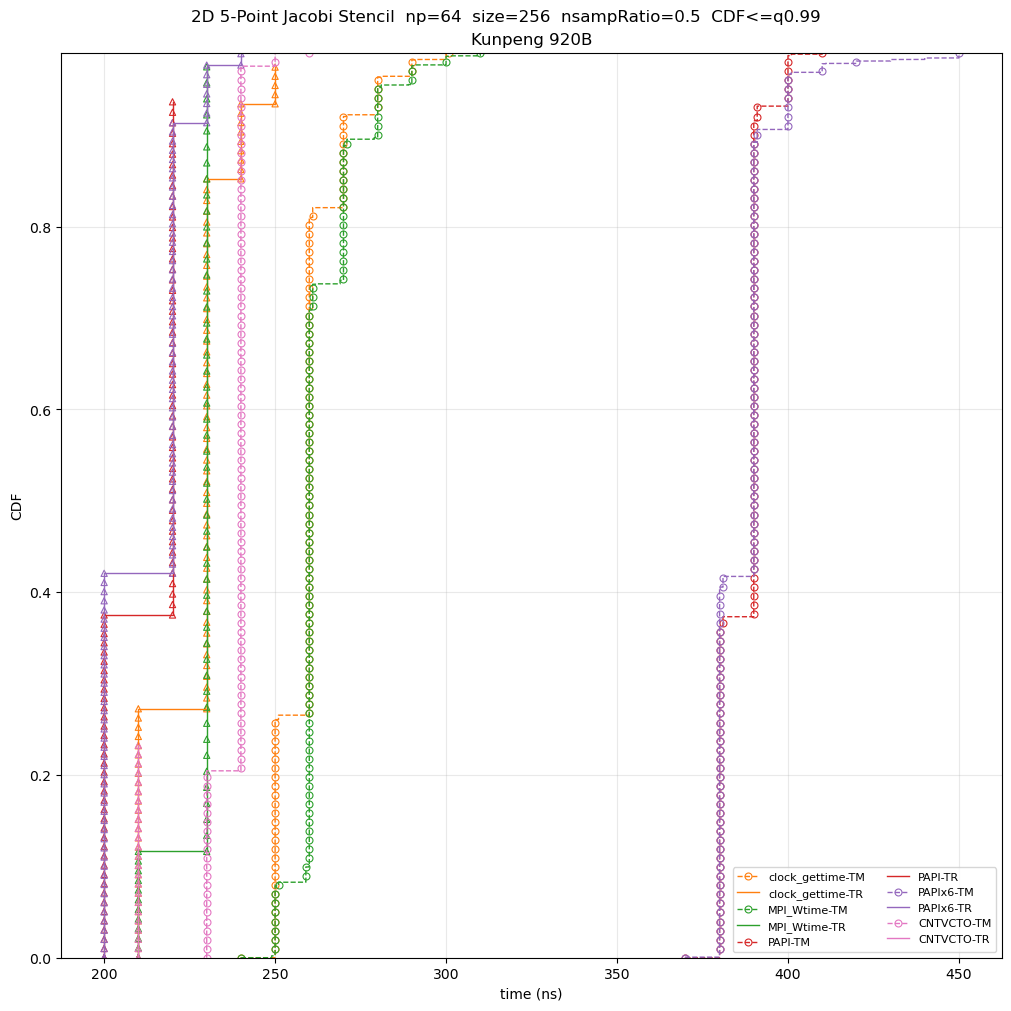

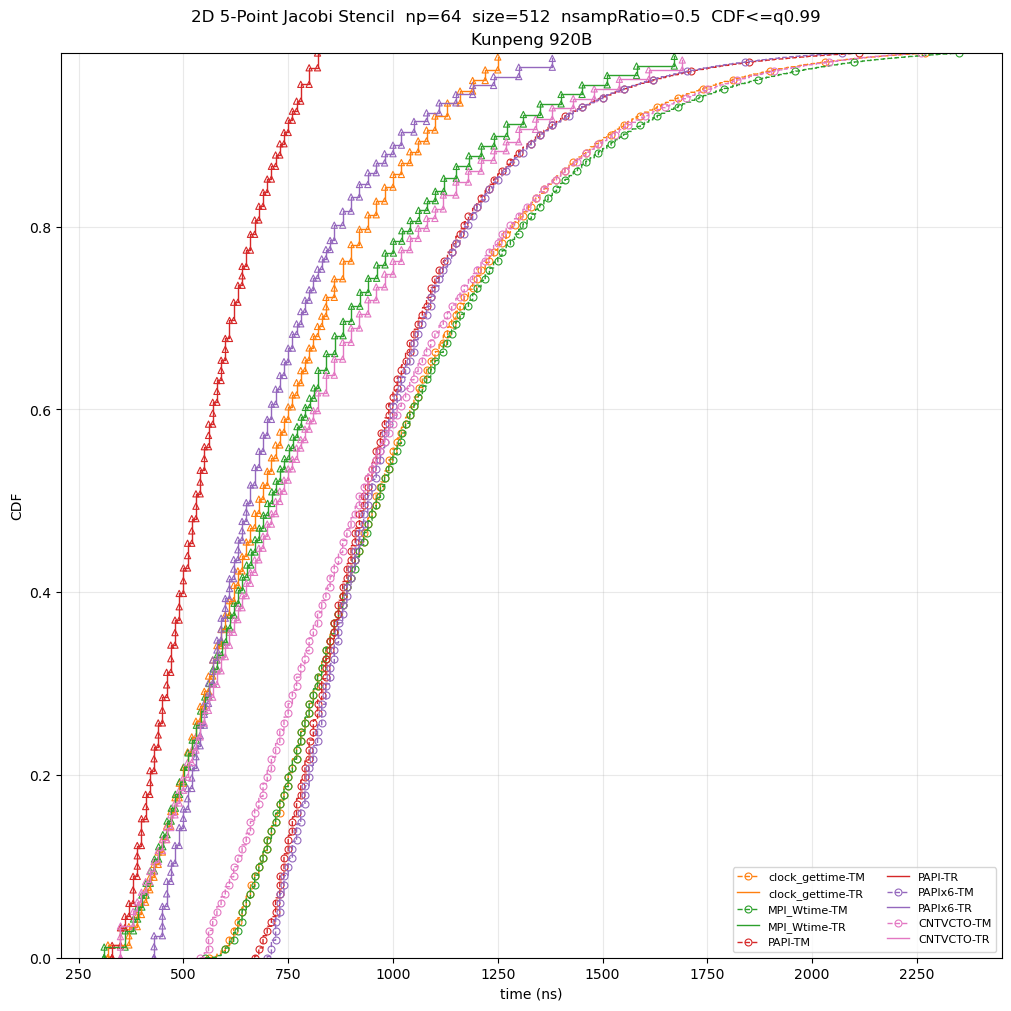

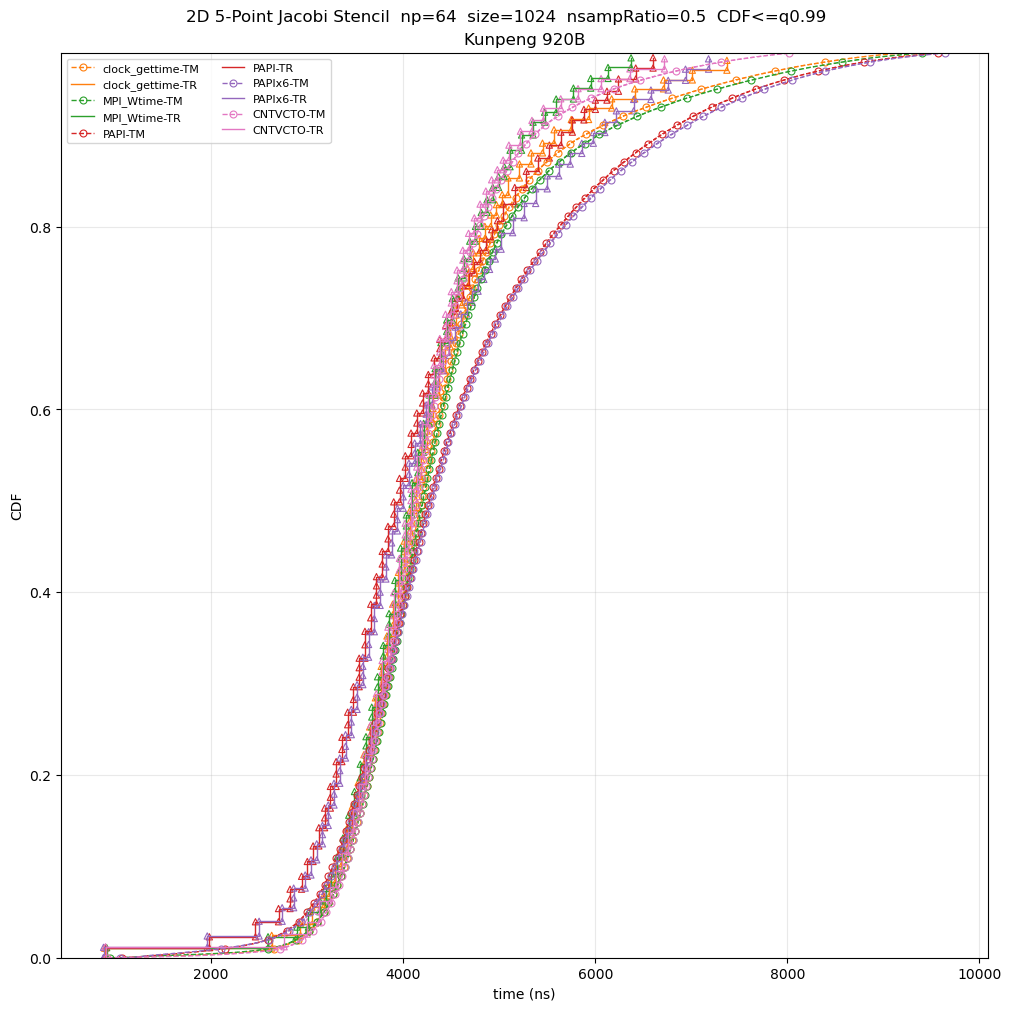

/astrum/home/hpchzy/miniconda3/envs/xfold-scripts/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


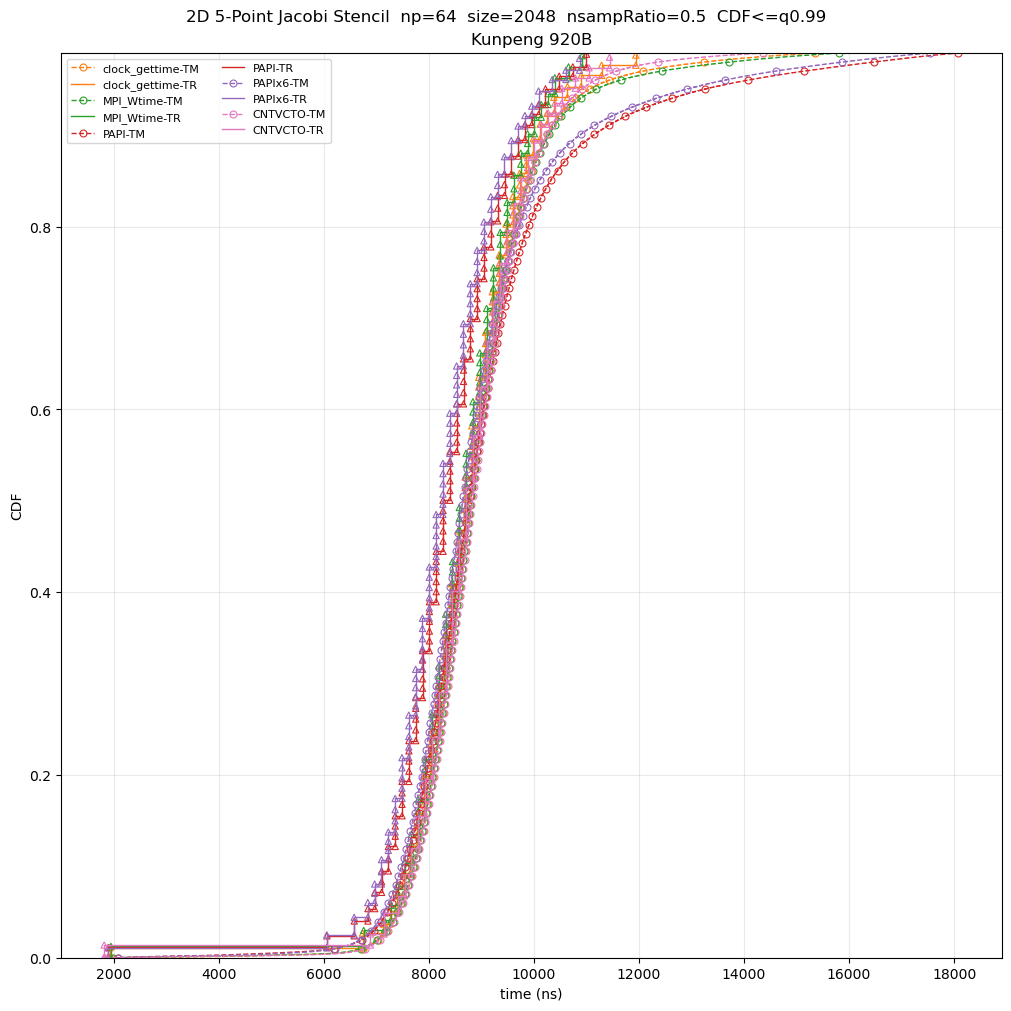

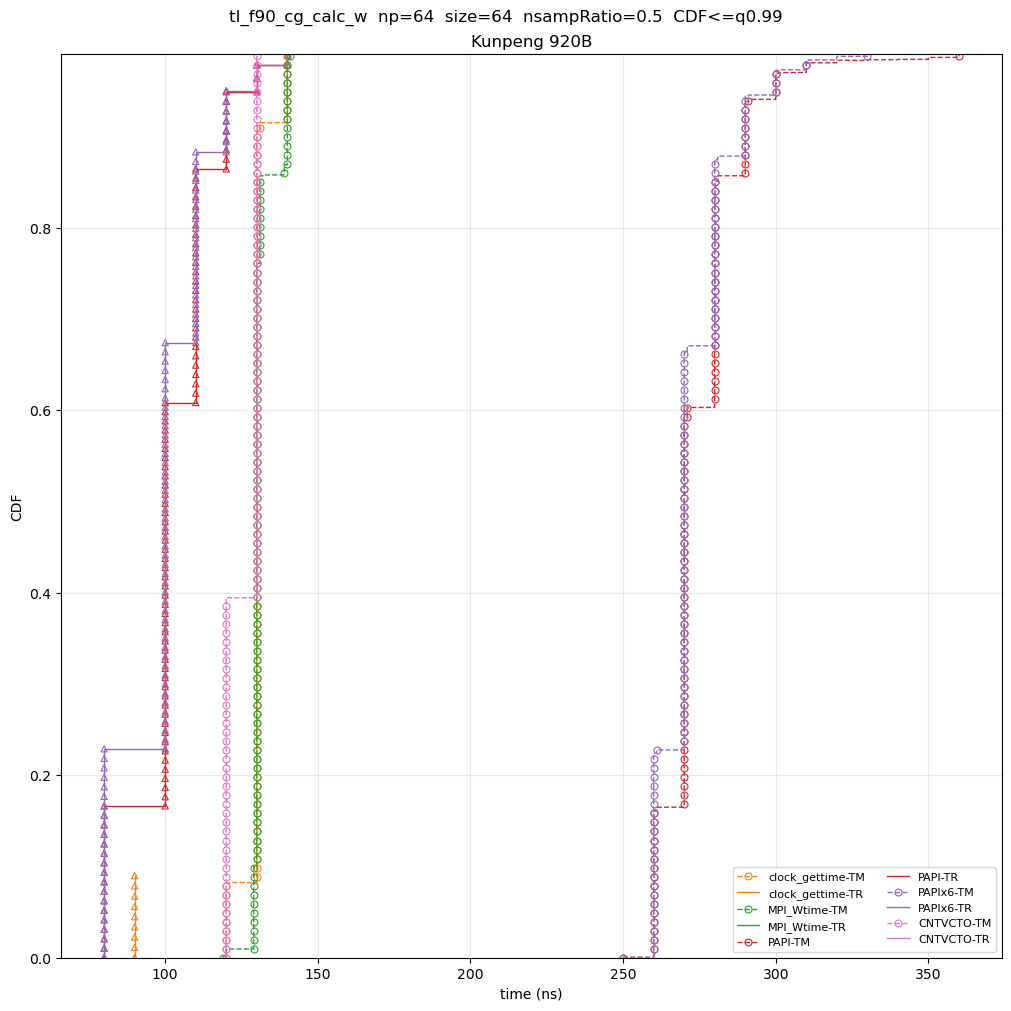

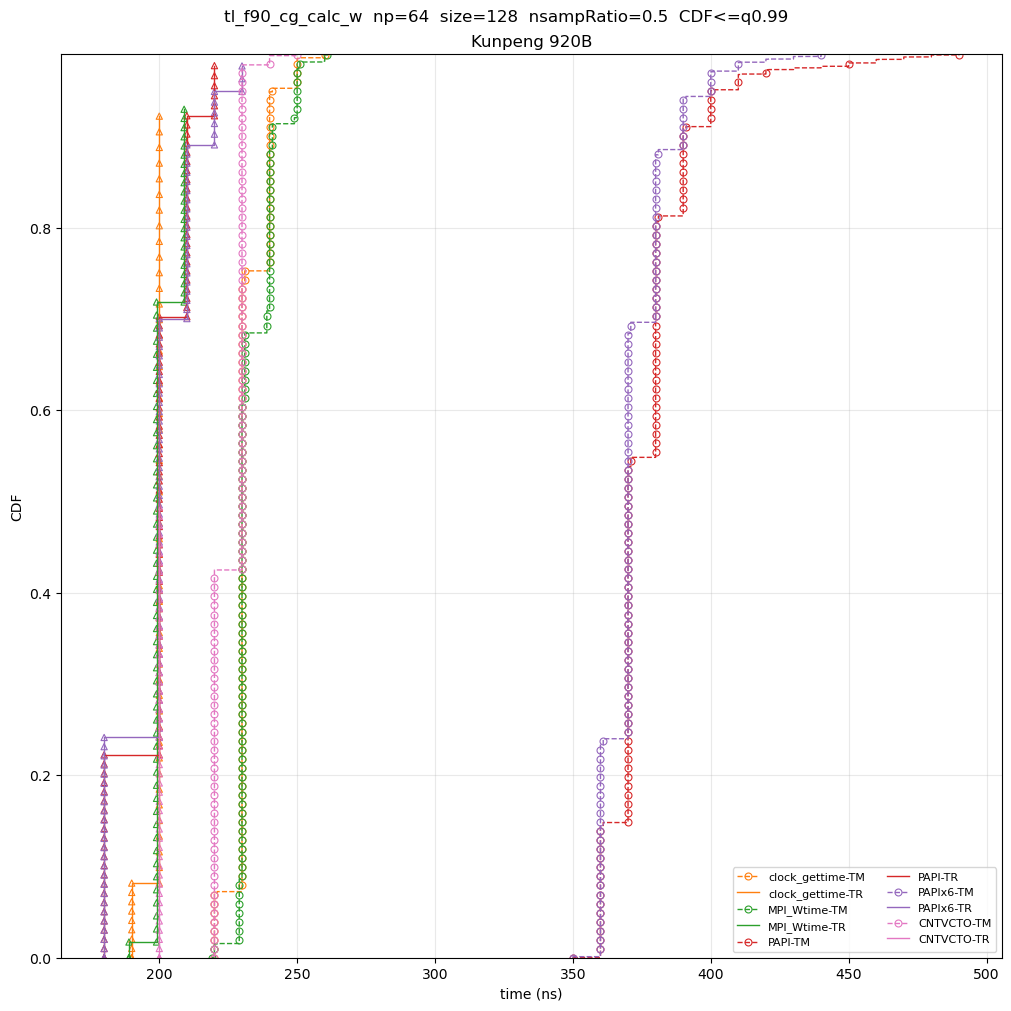

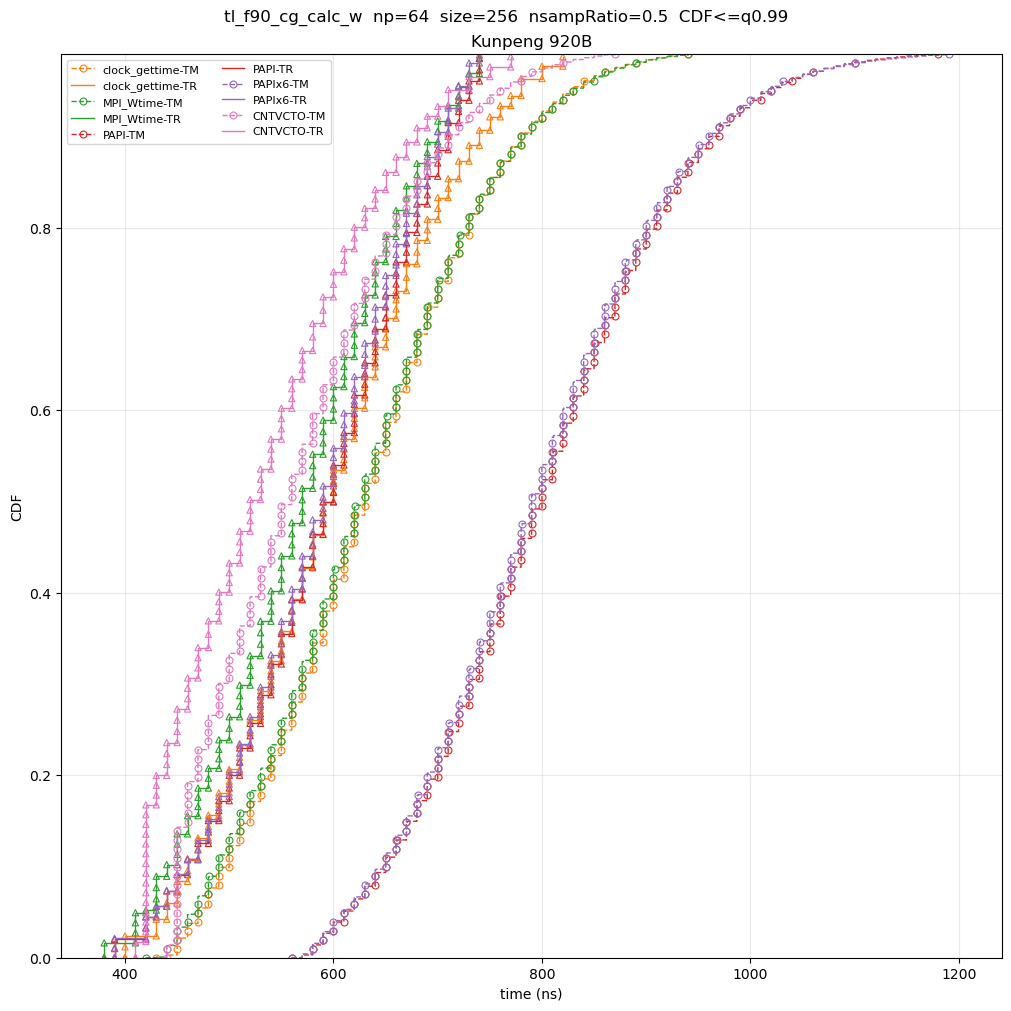

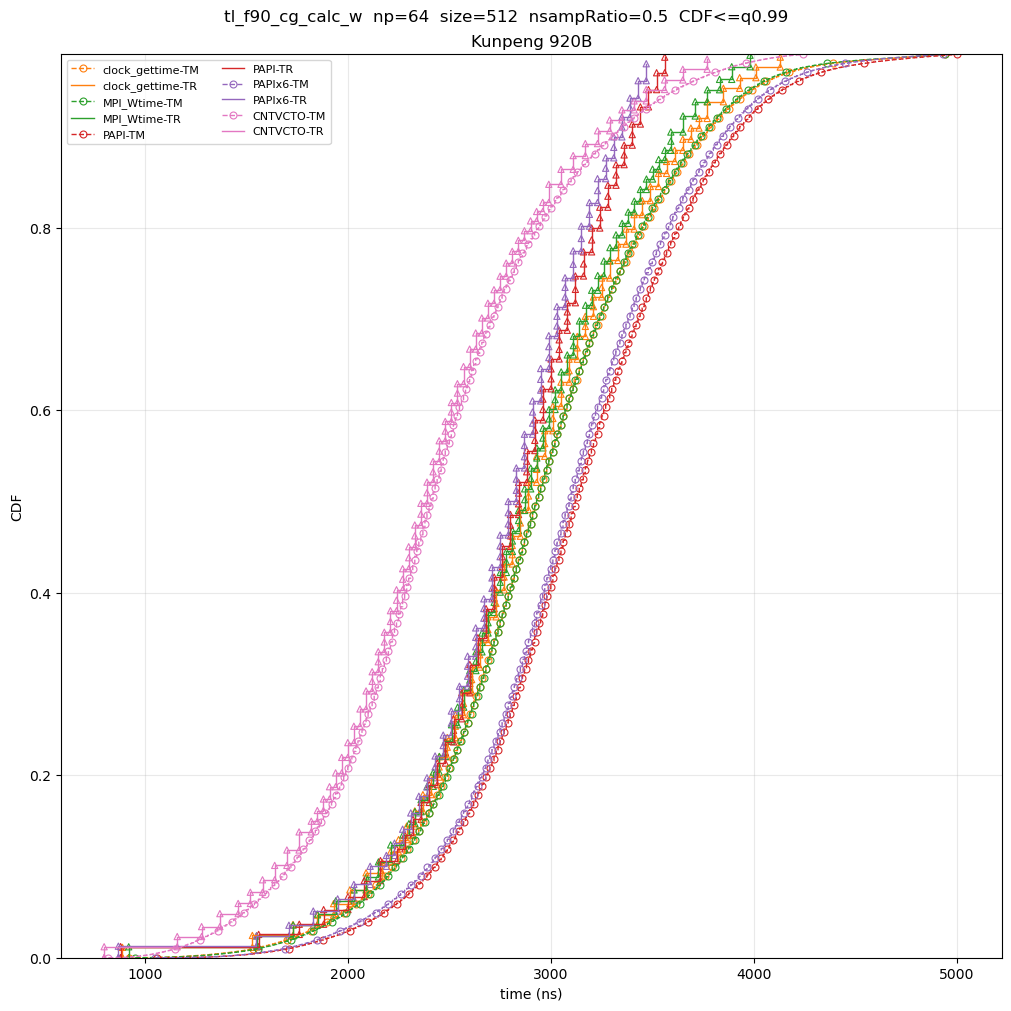

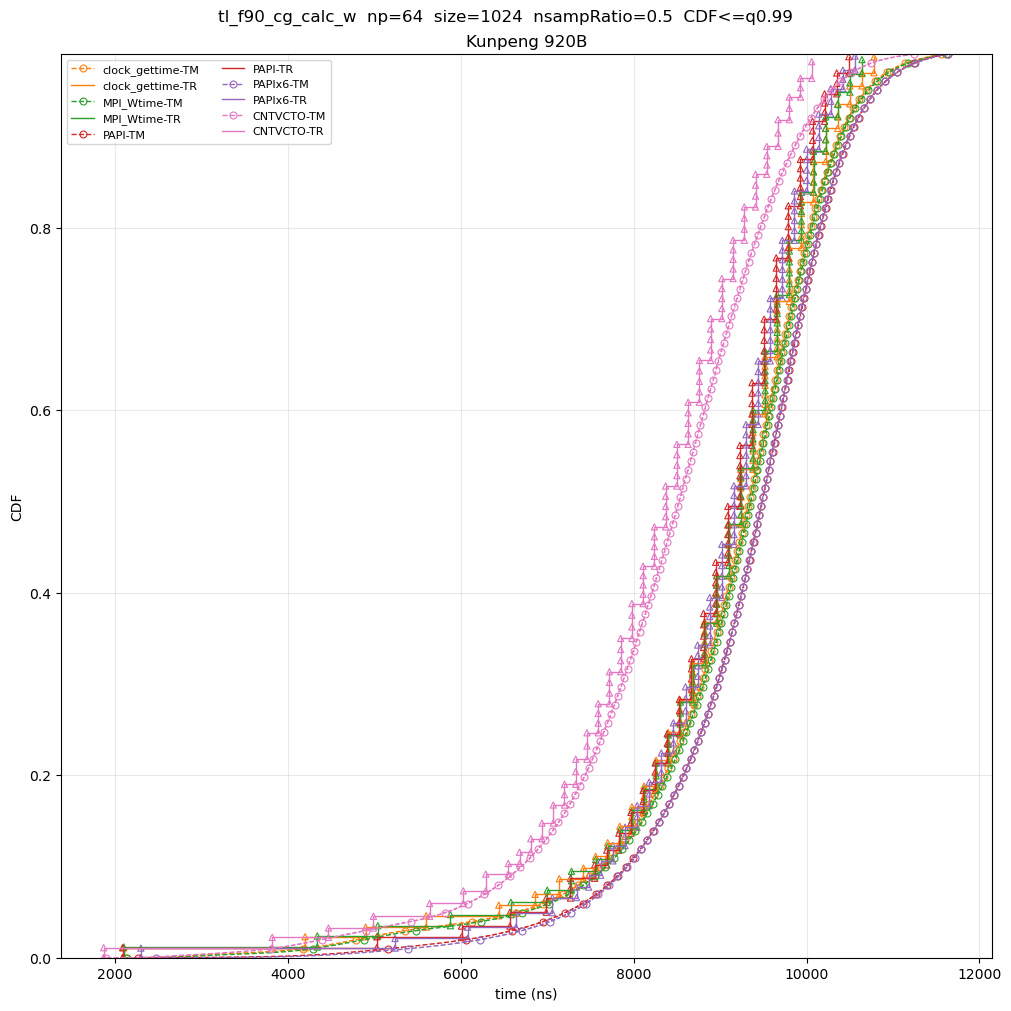

/astrum/home/hpchzy/miniconda3/envs/xfold-scripts/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


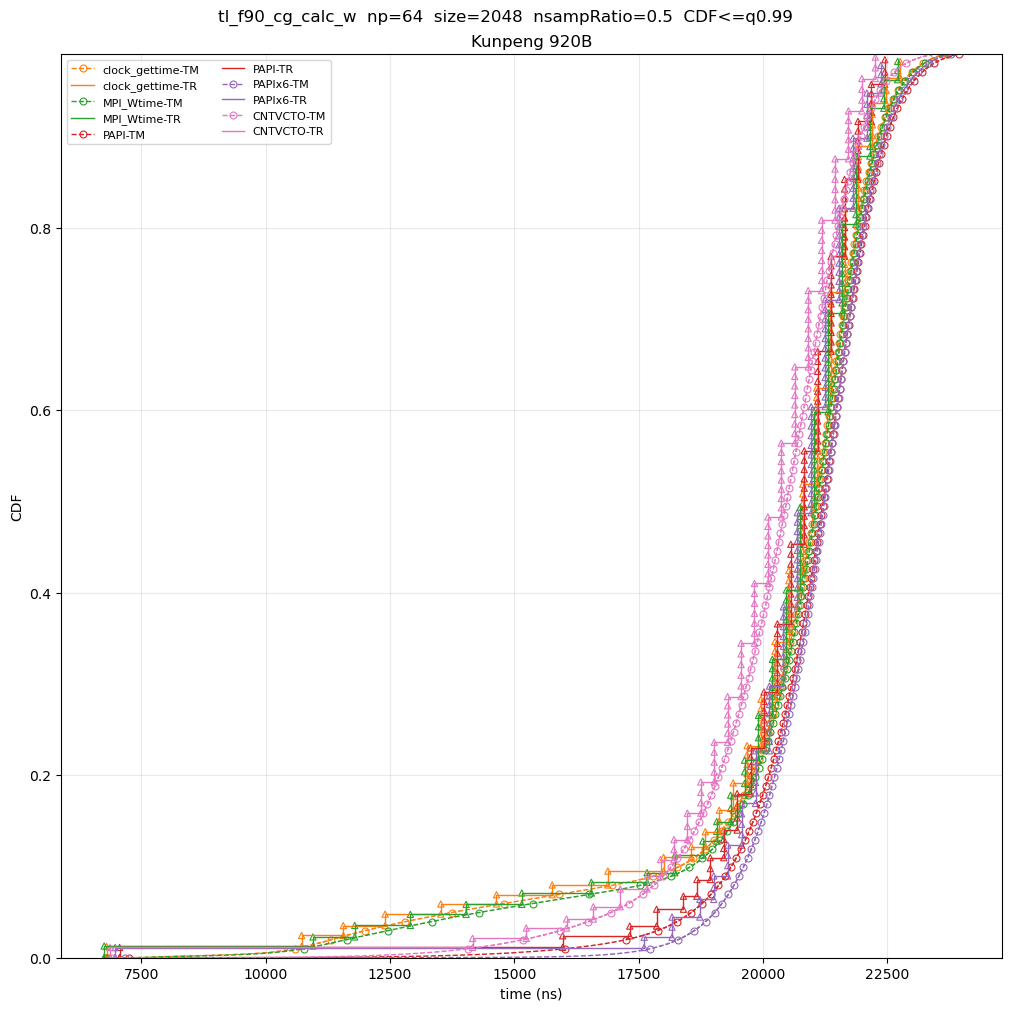

In [8]:
# entries_plot = entries[(entries['size'] == 2048) & (entries['timer'] != 'likwid')]
entries_plot = entries[(entries['size'] != '2048') & (entries['timer'] != 'likwid')]

print(entries_plot)


if entries_plot.empty:
    raise RuntimeError('No *_filt/tr_hist.csv entries found for size=2048 under DATA_FOLDERS')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]

for (kernel, np_val, size, nsamp_ratio), group_all in entries_plot.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    fig, axes = plt.subplots(1, len(hosts), figsize=(10.0 * len(hosts), 10), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            tm_x, tm_y = ecdf_xy(read_tm(row['tm_file']))
            tr_df = read_tr(row['tr_hist_file'])

            tm_markevery = max(10, len(tm_x) // 100)
            tr_x = np.repeat(tr_df['ns'].to_numpy(), 2)[1:]
            tr_y = np.repeat(tr_df['cdf'].to_numpy(), 2)[:-1]
            tr_ns = tr_df['ns'].to_numpy()
            tr_cdf = tr_df['cdf'].to_numpy()
            tr_prev = np.r_[0.0, tr_cdf[:-1]]
            tr_marker_x = []
            tr_marker_y = []
            for ns_i, y0, y1 in zip(tr_ns, tr_prev, tr_cdf):
                nmark = max(2, min(50, int(np.ceil((y1 - y0) / 0.01))))
                tr_marker_x.extend([ns_i] * nmark)
                tr_marker_y.extend(np.linspace(y0, y1, nmark))

            ax.step(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, where='post', marker='.', markevery=tm_markevery, markersize=10, markerfacecolor='none', markeredgewidth=0.8)
            ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0)
            ax.scatter(tr_marker_x, tr_marker_y, color=color, marker='^', s=20, linewidths=0.8, facecolor='none')

        ax.set_title(f"{HOST_LABELS.get(host, host)}")
        ax.set_xlabel('time (ns)')
        ax.set_ylim(0, QUANTILE_DROP)
        ax.grid(True, alpha=0.28)
        ax.legend(ncol=2, fontsize=8)

    xlims = [ax.get_xlim() for ax in axes]
    xlim = (min(lo for lo, hi in xlims), max(hi for lo, hi in xlims))
    for ax in axes:
        ax.set_xlim(xlim)
        ax.set_ylim(0, QUANTILE_DROP)

    axes[0].set_ylabel('CDF')
    fig.suptitle(f'{KERNEL_LABELS.get(kernel, kernel)}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  CDF<=q{QUANTILE_DROP}')

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()